<a href="https://colab.research.google.com/github/gustavox0/Tecnicas-Avanzdas-ML/blob/main/M7_AG1_Grupo17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **M7_AG1_Modelo de Sentimiento**

**Actividad grupal:** Grupo 17

**Módulo VII:** Técnicas Avanzadas de Machine Learning  

**Participantes:** Ariadna Moreno y Gustavo Salazar

#Contexto

IMDb (Internet Movie Database) es una base de datos de información de películas. Esta información incluye revisiones de las películas realizadas por los usuarios.
En esta práctica nos centraremos en analizar el sentimiento (positivo / negativo) de las revisiones.
Con todos estos datos, os pedimos lo siguiente:

# 1. Carga datasets

In [ ]:
#Carga de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import re
from collections import Counter
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Antes de comenzar vamos a revisar si tenemos disponible el entorno GPU

In [ ]:
gpu_available = False
if len(tf.config.list_physical_devices('GPU')) > 0:
  gpu_available = True
  print("Running on GPU")
else:
  print("Running on CPU")

Running on GPU


In [ ]:
# Carga del dataset

reviews_url = "https://raw.githubusercontent.com/md-lorente/Master_BD_DS/refs/heads/main/m%C3%B3dulo_7_aprendizaje_autom%C3%A1tico_para_machine_learning/reviews.txt"
labels_url = "https://raw.githubusercontent.com/md-lorente/Master_BD_DS/refs/heads/main/m%C3%B3dulo_7_aprendizaje_autom%C3%A1tico_para_machine_learning/labels.txt"

# Cargar archivos de texto sin encabezado
reviews = pd.read_csv(reviews_url, header=None, names=['review'])
labels = pd.read_csv(labels_url, header=None, names=['label'])

labels['label'] = labels['label'].apply(lambda x: 1 if x == 'positive' else 0)

In [ ]:
# Muestra las primeras 5 reseñas y etiquetas
for i in range(5):
    print(f"Reseña #{i+1}: {reviews.iloc[i]['review']}")
    print(f"Etiqueta: {labels.iloc[i]['label']}")
    print("---")

Reseña #1: bromwell high is a cartoon comedy . it ran at the same time as some other programs about school life  such as  teachers  . my   years in the teaching profession lead me to believe that bromwell high  s satire is much closer to reality than is  teachers  . the scramble to survive financially  the insightful students who can see right through their pathetic teachers  pomp  the pettiness of the whole situation  all remind me of the schools i knew and their students . when i saw the episode in which a student repeatedly tried to burn down the school  i immediately recalled . . . . . . . . . at . . . . . . . . . . high . a classic line inspector i  m here to sack one of your teachers . student welcome to bromwell high . i expect that many adults of my age think that bromwell high is far fetched . what a pity that it isn  t   
Etiqueta: 1
---
Reseña #2: story of a man who has unnatural feelings for a pig . starts out with a opening scene that is a terrific example of absurd comedy

In [ ]:
#dimensiones de los datasets
print(f"Dimensiones del dataset de reseñas: {reviews.shape}")
print(f"Dimensiones del dataset de etiquetas: {labels.shape}")

Dimensiones del dataset de reseñas: (25000, 1)
Dimensiones del dataset de etiquetas: (25000, 1)


# 2. Preprocesado

## Eliminar signos que no sean alfanuméricos

In [ ]:
#reemplazamos todo lo que no sea alfanumerico por un espacio y guardamos el texto limpio en reviews_clean
reviews_series = reviews.iloc[:, 0]
reviews_clean = []
for review in reviews_series:
    review = str(review)  # aseguramos que es string
    cleaned = re.sub(r"[^a-zA-Z0-9]", " ", review)
    reviews_clean.append(cleaned)

print(f"Total reviews_clean: {len(reviews_clean)}")
print(reviews_clean[:1]) #mostramos una reseña

Total reviews_clean: 25000
['bromwell high is a cartoon comedy   it ran at the same time as some other programs about school life  such as  teachers    my   years in the teaching profession lead me to believe that bromwell high  s satire is much closer to reality than is  teachers    the scramble to survive financially  the insightful students who can see right through their pathetic teachers  pomp  the pettiness of the whole situation  all remind me of the schools i knew and their students   when i saw the episode in which a student repeatedly tried to burn down the school  i immediately recalled                   at                     high   a classic line inspector i  m here to sack one of your teachers   student welcome to bromwell high   i expect that many adults of my age think that bromwell high is far fetched   what a pity that it isn  t   ']


## Tokenizar cada review

In [ ]:
tokenized_reviews = [word_tokenize(review) for review in reviews_clean]

In [ ]:
#mostrar 5 revies tokenizados y el número de palabras
for i in range(5):
    print(f"Reseña #{i+1}: {tokenized_reviews[i]}")
    print(f"Número de palabras: {len(tokenized_reviews[i])}")
    print("---")

Reseña #1: ['bromwell', 'high', 'is', 'a', 'cartoon', 'comedy', 'it', 'ran', 'at', 'the', 'same', 'time', 'as', 'some', 'other', 'programs', 'about', 'school', 'life', 'such', 'as', 'teachers', 'my', 'years', 'in', 'the', 'teaching', 'profession', 'lead', 'me', 'to', 'believe', 'that', 'bromwell', 'high', 's', 'satire', 'is', 'much', 'closer', 'to', 'reality', 'than', 'is', 'teachers', 'the', 'scramble', 'to', 'survive', 'financially', 'the', 'insightful', 'students', 'who', 'can', 'see', 'right', 'through', 'their', 'pathetic', 'teachers', 'pomp', 'the', 'pettiness', 'of', 'the', 'whole', 'situation', 'all', 'remind', 'me', 'of', 'the', 'schools', 'i', 'knew', 'and', 'their', 'students', 'when', 'i', 'saw', 'the', 'episode', 'in', 'which', 'a', 'student', 'repeatedly', 'tried', 'to', 'burn', 'down', 'the', 'school', 'i', 'immediately', 'recalled', 'at', 'high', 'a', 'classic', 'line', 'inspector', 'i', 'm', 'here', 'to', 'sack', 'one', 'of', 'your', 'teachers', 'student', 'welcome', '

## Generar lista de palabras
 Generar lista de palabras distintas de todo el dataset y ordenar por número de veces que se presenta en el dataset, de forma que se puedan seleccionar las "20,000" más frecuentes

In [ ]:
# Aplanar la lista de listas en una sola lista con todas las palabras
Palabras_dataset = [word.lower() for review in tokenized_reviews for word in review]

# Contar la frecuencia de cada palabra
Conteo_palabra = Counter(Palabras_dataset)

# Obtener las 20,000 palabras más frecuentes
Palabras_comunes = Conteo_palabra.most_common(20000)

# Mostrar las 10 primeras
print("Palabras más frecuentes:")
for palabra, count in Palabras_comunes[:10]:
    print(f"{palabra}: {count}")

Palabras más frecuentes:
the: 336713
and: 164107
a: 163009
of: 145864
to: 135720
is: 107328
br: 101872
it: 96352
in: 93968
i: 87623


## Identificar palabras de la lista

Asociar cada palabra de la lista con un número identificador

In [ ]:
palabra_to_index = {word: i for i, (word, count) in enumerate(Palabras_comunes)}

# Mostrar las primeras 5 palabras y su índice
for word, idx in list(palabra_to_index.items())[:5]:
    print(f"{word}: {idx}")

the: 0
and: 1
a: 2
of: 3
to: 4


## Truncar reviews

Truncar las reviews a 160 palabras y rellener con "0" las reviews que tengas menos palabras

In [ ]:
#Convertir las reviews tokenizadas a secuencias de indices
reviews_seq = []

for tokens in tokenized_reviews:
    seq = [palabra_to_index[word.lower()] for word in tokens if word.lower() in palabra_to_index]
    reviews_seq.append(seq)

#truncar/rellenar las secuencias a longitud de 160
max_len = 160
reviews_trunc = pad_sequences(reviews_seq, maxlen=max_len, padding='post', truncating='post')
#con 'post' agregamos 0s a las reviews menores a 160 y con post, truncamos a 160 las reviews más largas.

print("Shape final:", reviews_trunc.shape)  # debería ser (25000, 160)
print("Ejemplo de reseña procesada:", reviews_trunc[0])

Shape final: (25000, 160)
Ejemplo de reseña procesada: [  307     5     2  1048   206     7  2137    31     0   170    56    14
    49    80  5783    43   381   109   139    14  5193    59   153     8
     0  4974  5850   474    69     4   259    11   307    12  1977     5
    73  2394     4   611    72     5  5193     0     4  1982 10163     0
  5784  1498    35    48    65   203   144    66  1197  5193 19865     0
     3     0   220   881    30  2988    69     3     0  5785     9   684
     1    66  1498    53     9   215     0   382     8    61     2  1405
  3685   781     4  3482   179     0   381     9  1210 13580    31   307
     2   348   340  2914     9   142   126     4  7688    29     3   128
  5193  1405  2325     4   307     9   527    11   108  1447     3    59
   542   101    11   307     5   226  4145    47     2  2210    11     7
   214    22     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0   

## Dividir datasets

Dividir los datasets de reviews y etiquetas en 80% para entrenamiento, 10% para validación y 10% para prueba.

In [ ]:
# División inicial: 80% entrenamiento, 20% temporal (validación + prueba)
X_train, X_temp, y_train, y_temp = train_test_split(
    reviews_trunc, labels, test_size=0.2, random_state=42)

# División de los datos temporales en 50% validación y 50% prueba => 10% y 10%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: (20000, 160) (20000, 1)
Validación: (2500, 160) (2500, 1)
Prueba: (2500, 160) (2500, 1)


# 3. Carga fichero

Carga del fichero de palabras vectorizadas GloVe (https://materials.il3.ub.edu/cursos/tec_mbdds_taml/glove.6B/glove.6B.zip) de 100 dimensiones (se puede eliminar el resto de ficheros)

In [ ]:
# Cargamos el fichero de palabras vectorizadas de 100 dimensiones
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from time import time
import requests
import os
t_ini = time()

# carga del archivo .txt (sin ZIP)
file_path = "/content/drive/MyDrive/glove.6B.100d.txt"

# Mostrar las primeras 5 líneas directamente
print("Primeras 5 líneas del archivo:")
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        parts = line.strip().split()
        print(f"Línea {i+1}: {parts[0]} - {', '.join(parts[1:6])}...")

Primeras 5 líneas del archivo:
Línea 1: the - -0.038194, -0.24487, 0.72812, -0.39961, 0.083172...
Línea 2: , - -0.10767, 0.11053, 0.59812, -0.54361, 0.67396...
Línea 3: . - -0.33979, 0.20941, 0.46348, -0.64792, -0.38377...
Línea 4: of - -0.1529, -0.24279, 0.89837, 0.16996, 0.53516...
Línea 5: to - -0.1897, 0.050024, 0.19084, -0.049184, -0.089737...


Como se puede observar, el fichero de vectores globales (GloVe) contiene caracteres como "," y ".". Esto es importante porque en pasos previos realizamos una limpieza de caracteres no alfanuméricos en nuestros reviews, por lo que podriamos no estar aprovechando la riqueza del vocabulario de GloVe al no considerar signos de puntuación para nuestras reseñas.

In [ ]:
#cargar vectores GloVe en un diccionario
embedding_dim = 100
glove_index = {}

with open(file_path, encoding="utf8") as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype="float32")
        glove_index[word] = vector

# Crear la matriz de embeddings que se utilizará para pesos en modelo 2
vocab_size = len(palabra_to_index)
embedding_matrix = np.zeros((vocab_size, embedding_dim)) #inicializar en 0's

for word, i in palabra_to_index.items():
    embedding_vector = glove_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
#mostramos 2 elementos de la matriz
print(embedding_matrix[:2])

[[-0.038194   -0.24487001  0.72812003 -0.39961001  0.083172    0.043953
  -0.39140999  0.3344     -0.57545     0.087459    0.28786999 -0.06731
   0.30906001 -0.26383999 -0.13231    -0.20757     0.33395001 -0.33848
  -0.31742999 -0.48335999  0.1464     -0.37303999  0.34577     0.052041
   0.44946    -0.46970999  0.02628    -0.54154998 -0.15518001 -0.14106999
  -0.039722    0.28277001  0.14393     0.23464    -0.31020999  0.086173
   0.20397     0.52623999  0.17163999 -0.082378   -0.71787    -0.41531
   0.20334999 -0.12763     0.41367     0.55186999  0.57907999 -0.33476999
  -0.36559001 -0.54856998 -0.062892    0.26583999  0.30204999  0.99774998
  -0.80480999 -3.0243001   0.01254    -0.36941999  2.21670008  0.72201002
  -0.24978     0.92136002  0.034514    0.46744999  1.10790002 -0.19358
  -0.074575    0.23353    -0.052062   -0.22044     0.057162   -0.15806
  -0.30798    -0.41624999  0.37972     0.15006    -0.53211999 -0.20550001
  -1.25259995  0.071624    0.70564997  0.49744001 -0.420630

#4. Creacion del modelo 1

Definición de una Red Neuronal Recurrente para analizar el sentimiento de las reviews de películas del dataset.

    - El primer nivel será el embedding, cuya dimensión de salida será igual a la de los embeddings del fichero Glove. Estos embeddings serán entrenables: (trainable=True)
    - Añadir una capa LSTM
    - Añadir una capa lineal

En este modelo no se usa la matriz de pesos GloVe.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Definir el modelo
model = Sequential()

# Capa Embedding
model.add(Embedding(
    input_dim=len(palabra_to_index),    # tamaño del vocabulario
    output_dim=embedding_dim,           # 100 dimensiones (GloVe)
    trainable=True
))

# Capa LSTM
model.add(LSTM(64))  # usamos 64 como tamaño del estado oculto.

# Capa lineal de salida. Usamos "sigmoid" por ser un problema de clasificación binaria (positivo (1) / negativo (0))
model.add(Dense(1, activation='sigmoid'))

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Resumen del modelo
model.build(input_shape=(None, 160))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 160, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,042,305 (7.79 MB)

 Trainable params: 2,042,305 (7.79 MB)

 Non-trainable params: 0 (0.00 B)

#5. Entrenamiento del modelo 1

Entrenamiento del modelo 1 y ver el impacto en *loss* y *accuracy*

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5676 - loss: 0.6590 - val_accuracy: 0.8036 - val_loss: 0.4861
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8407 - loss: 0.4201 - val_accuracy: 0.6616 - val_loss: 0.7134
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6677 - loss: 0.6384 - val_accuracy: 0.6444 - val_loss: 0.6354
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6717 - loss: 0.6050 - val_accuracy: 0.5800 - val_loss: 0.6746
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6792 - loss: 0.6143 - val_accuracy: 0.6780 - val_loss: 0.5879
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7175 - loss: 0.5573 - val_accuracy: 0.6996 - val_loss: 0.5908
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7091 - loss: 0.5638 - val_accuracy: 0.7352 - val_loss: 0.5659
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8316 - loss: 0.4272 - val_accu

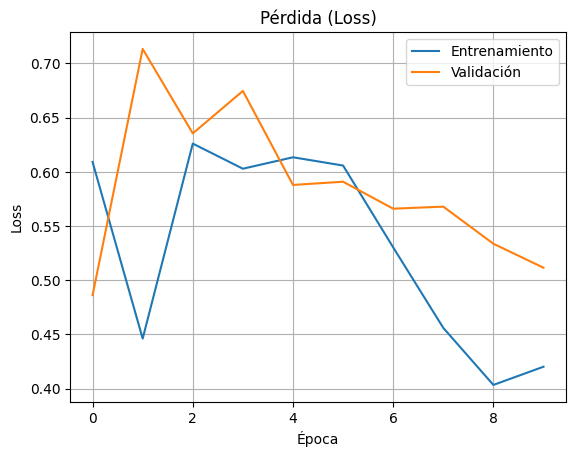

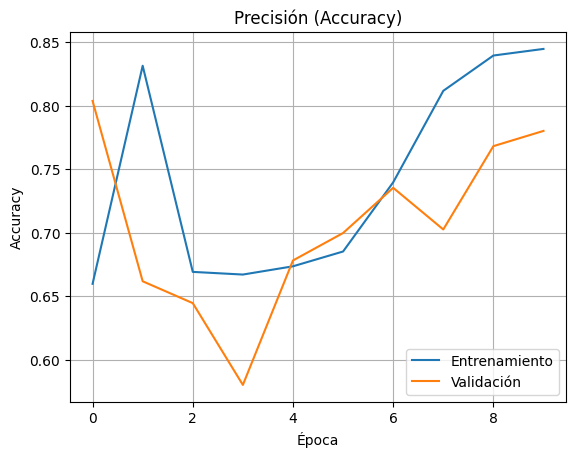

In [ ]:
# Entrenamiento del modelo
history = model.fit(
    X_train, y_train,
    epochs=10, #probamos con 10 epocas
    batch_size=128, #lotes de 128 reviews (al tener 20,000 datos en train, pasarà 20,000/128=156.25~157 veces en cada epoca)
    validation_data=(X_val, y_val)
)

# Gráfico de pérdida (loss)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Gráfico de precisión (accuracy)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

En este modelo, dado que no usamos el fichero preentrenado GloVe, los vectores se inicializan de manera aleatoria. A pesar de ello, desde la primera época los niveles de accuracy son buenos (entre 55% y 60%).

A partir de la época 5, el modelo empieza a sobreajustarse, ya que el accuracy en los datos de validación se estanca cerca del 80%, mientras que en los datos de entrenamiento sigue mejorando hasta superar el 90% en la época 8.

El sobreajuste también se observa a través de la pérdida: la pérdida en el conjunto de entrenamiento siempre disminuye, pero en los datos de validación comienza a aumentar a partir de la época 5.

# 6. Creación del modelo 2

Copiar la arquitectura del modelo 1 y añadir los siguientes cambios:

    - Añadir otro nivel a la red LSTM (parámetro n_layers).

    - Añadir bidireccionalidad.

    - Añadir capas de dropout.

    - Añadir otro nivel lineal

    - Sustituir los pesos de la capa de embeddings por los del fichero GloVe.

    - Con estas mejoras, intentad conseguir un *accuracy* superior al 80%.

Para este modelo utilizamos la matriz de vectores preentrenados de GloVe. Por ello, desde el inicio este modelo debe tener un desempeño mejor que el modelo 1 anterior, ya que con esta matriz de pesos el modelo inicia teniendo un conocimiento previo del vocabulario aportado por GloVe.

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model2 = Sequential()

# Capa 1 + pesos de embeddings con GloVe
model2.add(Embedding(input_dim=vocab_size,
                     output_dim=100,
                     input_length=max_len,
                     weights=[embedding_matrix],
                     trainable=True))

# Primera capa LSTM bidireccional + Dropout del 50%
model2.add(Bidirectional(LSTM(64, return_sequences=True)))
model2.add(Dropout(0.5))

# Segunda capa LSTM bidireccional con Dropout del 50%
model2.add(Bidirectional(LSTM(32)))
model2.add(Dropout(0.5))

# Capa densa intermedia lineal con Dropout del 50%
model2.add(Dense(32, activation='relu'))
model2.add(Dropout(0.5))

# Capa de salida sigmoide
model2.add(Dense(1, activation='sigmoid'))

# Compilar modelo
model2.compile(loss='binary_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# 7. Entrenamiento del modelo 2

Entrenamiento del modelo 2 y ver el impacto en loss y accuracy

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.5344 - loss: 0.6916 - val_accuracy: 0.7348 - val_loss: 0.5645
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7599 - loss: 0.5232 - val_accuracy: 0.8012 - val_loss: 0.4083
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8678 - loss: 0.3475 - val_accuracy: 0.8480 - val_loss: 0.3823
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9099 - loss: 0.2531 - val_accuracy: 0.8572 - val_loss: 0.3929
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9376 - loss: 0.1876 - val_accuracy: 0.8692 - val_loss: 0.4024
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9638 - loss: 0.1226 - val_accuracy: 0.8500 - val_loss: 0.5145
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9786 - loss: 0.0789 - val_accuracy: 0.8688 - val_loss: 0.5022
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9879 - loss: 0.0511 - val_

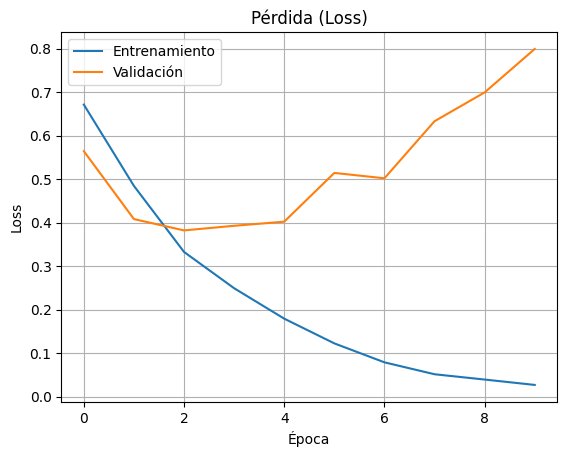

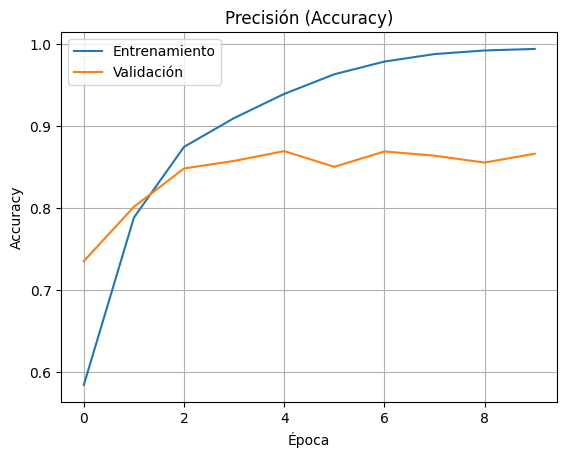

In [ ]:
history2 = model2.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      epochs=10,
                      batch_size=128)

# Gráfico de pérdida (loss)
plt.plot(history2.history['loss'], label='Entrenamiento')
plt.plot(history2.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Gráfico de precisión (accuracy)
plt.plot(history2.history['accuracy'], label='Entrenamiento')
plt.plot(history2.history['val_accuracy'], label='Validación')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

En este modelo utilizamos los vectores globales (GloVe) como matriz de pesos para la capa de embeddings durante el entrenamiento. Es decir, a diferencia del modelo 1, en este caso los vectores preentrenados aportan un conocimiento inicial, por lo que el modelo parte de relaciones semánticas ya establecidas entre las palabras de cada review, en lugar de iniciar con pesos aleatorios.

Como puede observarse, desde la época 2 el modelo alcanza una precisión (accuracy) superior al 85% tanto en el conjunto de entrenamiento como en el de validación. A partir de la época 4, el modelo presenta sobreajuste, ya que la precisión en validación se estanca alrededor del 85%, mientras que en entrenamiento continúa mejorando hasta llegar al 99% en la época 10. En los gráficos de pérdida (loss), se observa que a partir de la época 4 la pérdida en validación comienza a incrementarse, mientras que en entrenamiento sigue disminuyendo. Nuevamente, esto indica que a partir de la época 4 hay un sobreajuste del modelo.

#**Comparativo de modelos**

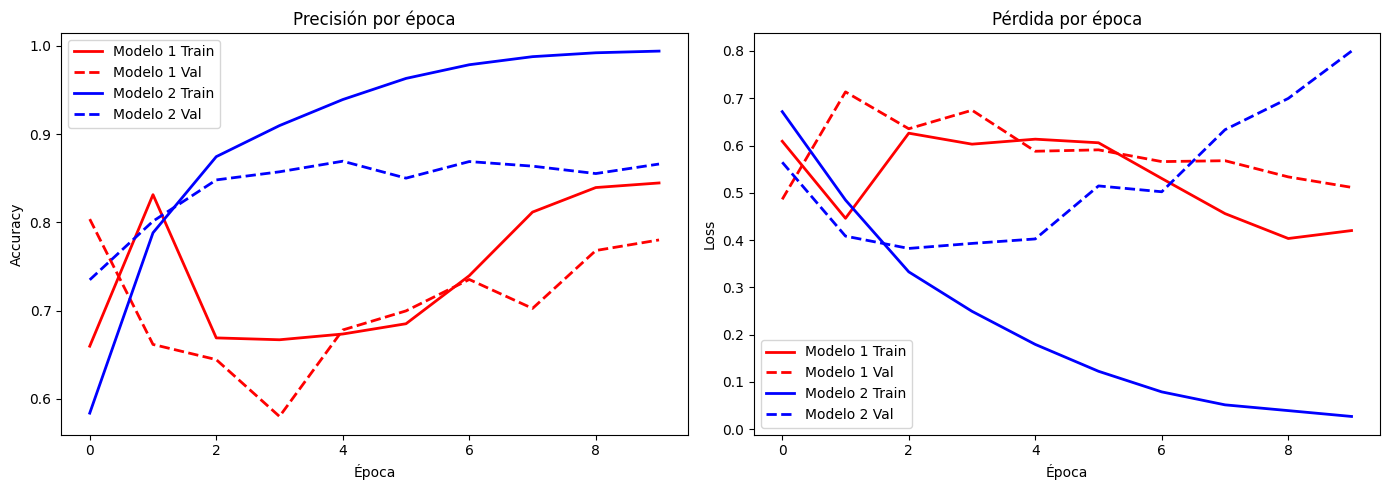

In [ ]:
import matplotlib.pyplot as plt

# Función para graficar precisión y pérdida
def plot_history(histories, names):
    plt.figure(figsize=(14, 5))

    # Colores y estilos personalizados
    model_colors = ['red', 'blue']  # Rojo para Modelo 1, Azul para Modelo 2
    line_styles = ['-', '--']       # Sólido para train, punteado para validation

    # Gráfico de Precisión (Accuracy)
    plt.subplot(1, 2, 1)
    for i, (history, name) in enumerate(zip(histories, names)):
        plt.plot(history.history['accuracy'],
                linestyle=line_styles[0],
                color=model_colors[i],
                linewidth=2,
                label=f'{name} Train')
        plt.plot(history.history['val_accuracy'],
                linestyle=line_styles[1],
                color=model_colors[i],
                linewidth=2,
                label=f'{name} Val')
    plt.title('Precisión por época', fontsize=12)
    plt.xlabel('Época', fontsize=10)
    plt.ylabel('Accuracy', fontsize=10)
    plt.legend()

    # Gráfico de Pérdida (Loss)
    plt.subplot(1, 2, 2)
    for i, (history, name) in enumerate(zip(histories, names)):
        plt.plot(history.history['loss'],
                linestyle=line_styles[0],
                color=model_colors[i],
                linewidth=2,
                label=f'{name} Train')
        plt.plot(history.history['val_loss'],
                linestyle=line_styles[1],
                color=model_colors[i],
                linewidth=2,
                label=f'{name} Val')
    plt.title('Pérdida por época', fontsize=12)
    plt.xlabel('Época', fontsize=10)
    plt.ylabel('Loss', fontsize=10)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Llamada con tus dos historiales
plot_history([history, history2], ["Modelo 1", "Modelo 2"])

En resumen, observamos que el modelo 1, que inicializa los vectores de palabras de manera aleatoria, alcanza niveles de precisión aceptables (cercanos al 85% en el conjunto de entrenamiento) en la época 4. No obstante, estos niveles son inferiores a los del modelo 2, que alcanza una precisión cercana al 95% en el conjunto de entrenamiento al utilizar relaciones semánticas previas entre las palabras mediante GloVe.

En las curvas de pérdida, también observamos que ambos modelos comienzan a sobreajustarse a partir de la época 4.

Finalmente, es importante considerar el tiempo de entrenamiento de ambos modelos. El modelo 1 comienza el entrenamiento desde cero (al inicializar vectores de manera aleatoria) y, aunque solo incluye tres niveles, el tiempo de entrenamiento para lotes de 128 y 10 épocas no es elevado. En contraste, en el modelo 2 se parte de relaciones semánticas preestablecidas (por GloVe), lo que podría suponer un entrenamiento más rápido; sin embargo, añadimos niveles adicionales, capas dropout y bidireccionalidad, por lo que se dio mayor profundidad al modelo y, por tanto, requiere mayor tiempo de entrenamiento que el modelo 1. Esta mayor profundidad dio mayor capacidad de generalización.

En definitiva, usar embeddings semánticos como GloVe mejora significativamente el rendimiento en el análisis de sentimientos, aunque se requiera un tiempo de entrenamiento superior.